In [69]:
!pip install tensorflow pandas scikit-learn matplotlib keras-tuner


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import keras_tuner as kt
import random

print("Cell 1: Libraries imported.")

seed_value = 42 # You can use any integer
tf.random.set_seed(seed_value)
np.random.seed(seed_value)
random.seed(seed_value)

Cell 1: Libraries imported.


In [71]:
# --- This cell is configured for the Baseline Model (Price Only) ---
filename = 'BTC.csv'
# -----------------------------------------------------------------

# Load the data
try:
    df = pd.read_csv(filename)
except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found.")
    exit()

# Select ONLY the close_price as our feature
features = ['close_price']
df = df.dropna(subset=features)
dataset = df[features].values.reshape(-1, 1) # Reshape for single feature

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_dataset = scaler.fit_transform(dataset)

print(": Baseline dataset (price only) loaded and scaled.")

: Baseline dataset (price only) loaded and scaled.


In [72]:
def create_sequences(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

# Split into training (80%) and testing (20%) sets
train_size = int(len(scaled_dataset) * 0.8)
train_data, test_data = scaled_dataset[0:train_size, :], scaled_dataset[train_size:len(scaled_dataset), :]

# Define the lookback period
look_back = 60

# Create the sequences for training and testing
X_train, y_train = create_sequences(train_data, look_back)
X_test, y_test = create_sequences(test_data, look_back)

# Reshape input to be [samples, time steps, features]
# The number of features is 1 for the baseline model
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Cell : Training and testing sequences created.")

Cell : Training and testing sequences created.


In [73]:
def build_model(hp):
    """
    This function builds the LSTM model and defines the hyperparameter search space.
    """
    model = Sequential()

    # Define Hyperparameter Search Space
    hp_units = hp.Int('units', min_value=32, max_value=128, step=16)
    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    # Build the model using the hyperparameters
    # Note the input_shape now has 1 feature
    model.add(LSTM(units=hp_units, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(rate=hp_dropout))
    model.add(LSTM(units=hp_units, return_sequences=False))
    model.add(Dropout(rate=hp_dropout))
    model.add(Dense(units=1))

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='mean_squared_error'
    )
    
    return model

print(": Hyperparameter model builder function created.")

: Hyperparameter model builder function created.


In [74]:
# Instantiate the tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_loss', # The metric to minimize
    max_epochs=50,
    factor=3,
    directory='lstm_tuner',
    project_name='btc_baseline' # New project name for the baseline
)

# Create a callback to stop training early
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

print("Starting hyperparameter search... (This will take a significant amount of time)")
tuner.search(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[stop_early]
)

print("\nCell : Hyperparameter search complete.")

Reloading Tuner from lstm_tuner/btc_baseline/tuner0.json
Starting hyperparameter search... (This will take a significant amount of time)

Cell : Hyperparameter search complete.


In [75]:
# Get the optimal hyperparameters from the tuner
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete. 
The optimal number of units in the LSTM layers is {best_hps.get('units')}.
The optimal dropout rate is {best_hps.get('dropout')}.
The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
""")

print("\nCell : Best hyperparameters retrieved.")


The hyperparameter search is complete. 
The optimal number of units in the LSTM layers is 80.
The optimal dropout rate is 0.2.
The optimal learning rate for the optimizer is 0.01.


Cell : Best hyperparameters retrieved.


In [87]:
# Build the model with the optimal hyperparameters
final_model = tuner.hypermodel.build(best_hps)

print("Retraining the best model on the full training data... (This will take some time)")

# Retrain the model
history = final_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)]
)

print("\nCell : Final model training complete.")

Retraining the best model on the full training data... (This will take some time)
Epoch 1/50


/Users/hamza/Desktop/Thesis/thesis_env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0249 - val_loss: 7.4053e-04
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0023 - val_loss: 4.6260e-04
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0018 - val_loss: 4.2684e-04
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0019 - val_loss: 3.5750e-04
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0016 - val_loss: 3.3949e-04
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0015 - val_loss: 4.1474e-04
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013 - val_loss: 5.9617e-04
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0015 - val_loss: 5.2081e-04
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 8.5060e-04
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0018 - val_loss: 3.9254e-04
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0012 - val_loss: 2.4531e-04
Epoch 12/50
44/44 ━━━━━━━━━━━━

In [88]:
# Make predictions on the test set using the final, retrained model
predictions_scaled = final_model.predict(X_test)

# Inverse the scaling to get actual price values
predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Cell : Predictions made with the final optimal model.")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Cell : Predictions made with the final optimal model.


In [89]:
# --- This is the new, upgraded evaluation cell ---

# --- Quantitative Metrics (RMSE & MAE) ---
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)

# --- Create a DataFrame for Directional Accuracy Analysis ---
# We need to align the true prices with the predictions.
# The first prediction corresponds to the price at index `train_size + look_back`.
results_df = pd.DataFrame({
    'true_price': y_test_actual.flatten(),
    'predicted_price': predictions.flatten()
}, index=df.index[train_size + look_back : train_size + look_back + len(y_test_actual)])


# --- 1. Short-Term (1-Day) Directional Accuracy ---
# This is the original method.
# It checks if the model correctly predicted if the next day's price would be up or down compared to the day before.
results_df['true_direction_1d'] = np.sign(results_df['true_price'].diff())
results_df['predicted_direction_1d'] = np.sign(results_df['predicted_price'].diff())
correct_predictions_1d = (results_df['true_direction_1d'] * results_df['predicted_direction_1d'] >= 0).sum()
directional_accuracy_1d = correct_predictions_1d / len(results_df.dropna())


# --- 2. Long-Term (7-Day) Directional Accuracy ---
# Here, we check if the model's prediction for TOMORROW can predict the trend for the NEXT 7 DAYS.
# The predicted direction is simply whether the model thinks tomorrow's price is higher than today's.
results_df['predicted_direction_longterm'] = np.sign(results_df['predicted_price'] - results_df['true_price'].shift(1))

# The actual long-term direction is whether the price in 7 days is higher than today's price.
results_df['true_direction_7d'] = np.sign(results_df['true_price'].shift(-6) - results_df['true_price'])
correct_predictions_7d = (results_df['predicted_direction_longterm'] * results_df['true_direction_7d'] >= 0).sum()
directional_accuracy_7d = correct_predictions_7d / len(results_df.dropna())


# --- 3. Long-Term (30-Day) Directional Accuracy ---
# Same logic, but for a 30-day horizon.
results_df['true_direction_30d'] = np.sign(results_df['true_price'].shift(-29) - results_df['true_price'])
correct_predictions_30d = (results_df['predicted_direction_longterm'] * results_df['true_direction_30d'] >= 0).sum()
directional_accuracy_30d = correct_predictions_30d / len(results_df.dropna())


# --- Print All Results ---
print("\n--- Final Optimized Baseline Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print("---------------------------------------------")
print(f"Directional Accuracy (1-Day Horizon): {directional_accuracy_1d:.2%}")
print(f"Directional Accuracy (7-Day Horizon): {directional_accuracy_7d:.2%}")
print(f"Directional Accuracy (30-Day Horizon): {directional_accuracy_30d:.2%}")
print("\nCell : Performance metrics calculated.")


--- Final Optimized Baseline Model Evaluation ---
Root Mean Squared Error (RMSE): $1081.37
Mean Absolute Error (MAE): $823.58
---------------------------------------------
Directional Accuracy (1-Day Horizon): 49.84%
Directional Accuracy (7-Day Horizon): 51.84%
Directional Accuracy (30-Day Horizon): 46.38%

Cell : Performance metrics calculated.


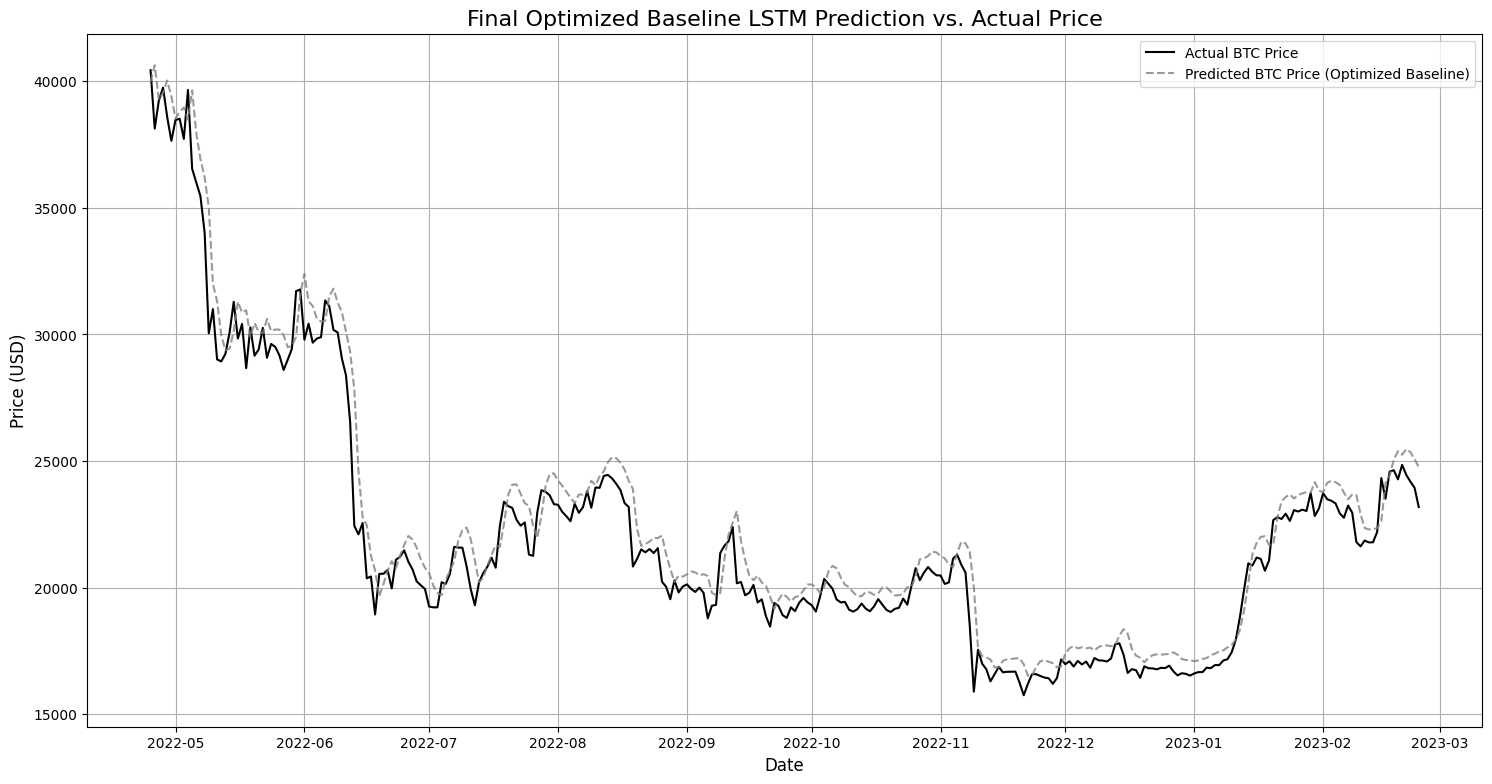


Cell : Visualization generated. Analysis finished.


In [90]:
# Make sure the 'date' column is in datetime format
df['date'] = pd.to_datetime(df['begins_at'])

# Find the start date of the test set for plotting
plot_dates = df['date'].iloc[len(df) - len(predictions):]

plt.figure(figsize=(18, 9))
plt.plot(plot_dates, y_test_actual, color='black', label='Actual BTC Price')
plt.plot(plot_dates, predictions, color='gray', linestyle='--', alpha=0.8, label='Predicted BTC Price (Optimized Baseline)')
plt.title('Final Optimized Baseline LSTM Prediction vs. Actual Price', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True)
plt.savefig('lstm_tuned_prediction_baseline.png')
plt.show()

print("\nCell : Visualization generated. Analysis finished.")

In [91]:
# --- Advanced Analysis: Volatility Regime Performance (Corrected) ---
# This cell assumes you have already run the model and have the following variables in memory:
# - df: The original dataframe with the full history
# - y_test_actual: The true prices for the test set
# - predictions: The model's predicted prices for the test set

try:
    # 1. Create a results dataframe with the correct date index
    # Get the actual dates for the test set predictions
    test_dates = df['date'].iloc[len(df) - len(predictions):]
    results_df = pd.DataFrame({
        'true_price': y_test_actual.flatten(),
        'predicted_price': predictions.flatten()
    }, index=pd.to_datetime(test_dates))


    # 2. Calculate daily returns and rolling volatility on the original full dataframe
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    df['daily_return'] = df['close_price'].pct_change()
    df['volatility'] = df['daily_return'].rolling(window=30).std()


    # 3. Join the volatility data with the results dataframe
    # The join now works correctly because both dataframes share a datetime index
    regime_df = results_df.join(df['volatility']).dropna()


    # 4. Define the volatility regimes using quantiles (dividing data into three equal parts)
    low_vol_threshold = regime_df['volatility'].quantile(0.33)
    high_vol_threshold = regime_df['volatility'].quantile(0.66)

    def assign_regime(volatility):
        if volatility <= low_vol_threshold:
            return 'Low Volatility'
        elif volatility <= high_vol_threshold:
            return 'Normal Volatility'
        else:
            return 'High Volatility'

    regime_df['regime'] = regime_df['volatility'].apply(assign_regime)


    # 5. Calculate performance metrics for each regime
    print("\n--- Performance by Market Regime ---")

    for regime, group_df in regime_df.groupby('regime'):
        # Ensure the group is not empty
        if len(group_df) < 2:
            print(f"\nSkipping {regime}: Not enough data points.")
            continue

        rmse = np.sqrt(mean_squared_error(group_df['true_price'], group_df['predicted_price']))
        
        # Calculate directional accuracy for the subset
        group_df['true_direction'] = np.sign(group_df['true_price'].diff())
        group_df['predicted_direction'] = np.sign(group_df['predicted_price'].diff())
        
        # Calculate correct predictions, handling potential NaNs from diff()
        correct_predictions = (group_df['true_direction'] * group_df['predicted_direction'] >= 0).sum()
        directional_accuracy = correct_predictions / len(group_df.dropna(subset=['true_direction', 'predicted_direction']))
        
        print(f"\nResults for {regime} ({len(group_df)} days):")
        print(f"  - RMSE: ${rmse:.2f}")
        print(f"  - Directional Accuracy: {directional_accuracy:.2%}")

except NameError:
    print("Error: Please make sure you have run the full LSTM training and prediction script first.")
except Exception as e:
    print(f"An error occurred: {e}")


--- Performance by Market Regime ---

Results for High Volatility (104 days):
  - RMSE: $1319.14
  - Directional Accuracy: 47.57%

Results for Low Volatility (101 days):
  - RMSE: $790.96
  - Directional Accuracy: 51.00%

Results for Normal Volatility (101 days):
  - RMSE: $1060.85
  - Directional Accuracy: 54.00%


In [92]:
model_name="LSTM_Baseline"

In [93]:

# ## 12. Save Final Predictions to a File
# This cell takes the final 'true_price' and 'predicted_price' and saves them
# to a CSV file. This allows for easy comparison with other models later.

# Create a dataframe from the results
# The index will be the date, which is important for alignment later
predictions_df = pd.DataFrame({
    'true_price': y_test_actual.flatten(),
    'predicted_price': predictions.flatten()
}, index=plot_dates)

# Define the output filename using the model_name from Cell 2
output_filename = f'predictions_{model_name}.csv'

# Save to CSV
predictions_df.to_csv(output_filename)

print(f"\nCell 12/12: Predictions saved successfully to '{output_filename}'")


Cell 12/12: Predictions saved successfully to 'predictions_LSTM_Baseline.csv'


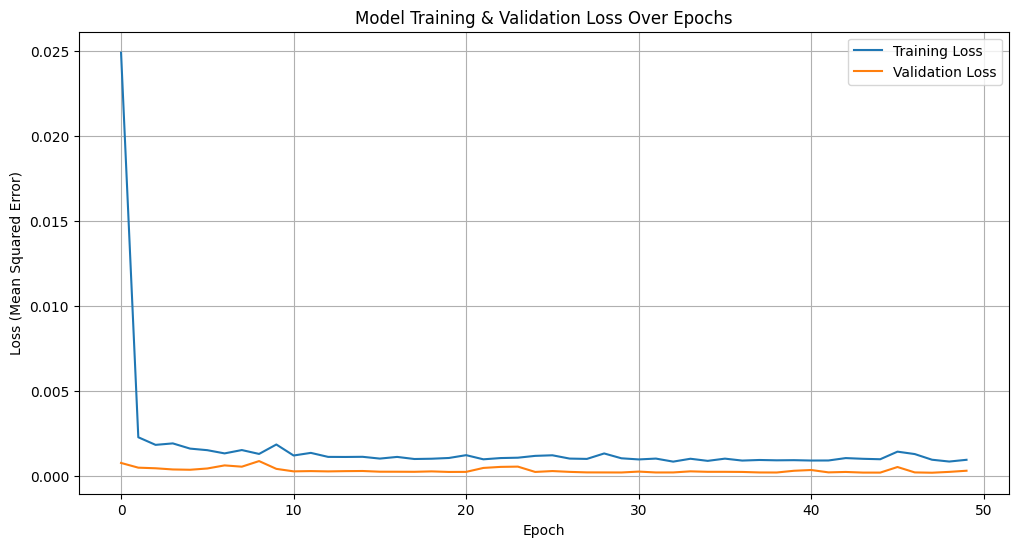

In [94]:
# --- ADD THIS CELL TO PLOT TRAINING & VALIDATION LOSS ---

# Create a plot for the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training & Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.savefig('lstm_tuned_loss_curve_baseline.png')
plt.show()